# 06 · H3: Supply-driven vs demand-driven oil shocks

**Theory (L22, offer curves).**
- **Case A, supply shock:** only the rest-of-world curve shifts in, so India's ToT should fall.
- **Case B, world demand boom:** world demand for India's exports also rises, which should *soften* the ToT loss.

**H3:** supply-driven oil price rises hurt India's ToT more than demand-driven ones.

**Method (two steps):**
1. Split every monthly oil price change (1975–2026) into a **supply-driven** part and a **demand-driven** part. We regress the change on Baumeister & Hamilton's (2019, AER) identified shocks: oil supply, economic activity, oil consumption demand and oil inventory demand (current + 2 lags). The fitted contribution of the supply shocks is the supply part; the rest of the fitted value is the demand part.
2. Regress India's ToT changes on the two parts and test whether their coefficients differ.

This answers: *does it matter WHY oil became expensive?*

In [1]:
# Shared setup: the helper modules live in ../src (chart style, econometrics helpers, data loader)
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from style import *
import econ
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
m, a, c = econ.load()

In [2]:
s = m.loc["1975-02":"2026-03", ["oil_avg", "bh_supply", "bh_activity", "bh_consumption_demand", "bh_inventory_demand"]].copy()
s["dlp"] = 100 * np.log(s.oil_avg).diff()
shocks = ["bh_supply", "bh_activity", "bh_consumption_demand", "bh_inventory_demand"]
for k in shocks:
    for j in (1, 2):
        s[f"{k}_l{j}"] = s[k].shift(j)
rhs = shocks + [f"{k}_l{j}" for k in shocks for j in (1, 2)]
st1 = smf.ols("dlp ~ " + " + ".join(rhs), data=s.dropna()).fit()
p = st1.params
s["supply_part"] = sum(p[c] * s[c] for c in p.index if c.startswith("bh_supply"))
s["demand_part"] = sum(p[c] * s[c] for c in p.index if c.startswith("bh_") and not c.startswith("bh_supply"))
print(f"Step 1: R² = {st1.rsquared:.2f}, N = {int(st1.nobs)} months.  Supply-shock coefficient (t): {p['bh_supply']:.2f} "
      f"(negative = a favourable supply shock lowers the price, as it should)")
s.loc["2026-01":"2026-03", ["dlp", "supply_part", "demand_part"]].round(1)

Step 1: R² = 0.80, N = 612 months.  Supply-shock coefficient (t): -2.36 (negative = a favourable supply shock lowers the price, as it should)


,dlp,supply_part,demand_part
date,,,
2026-01-01,4.500,6.100,-1.000
2026-02-01,6.500,-2.500,4.800
2026-03-01,34.100,36.400,-5.500


In March 2026 (Hormuz), the model attributes the 34% oil price jump almost entirely to the **supply** part. In February–March 2022 the rise was mainly **demand**-driven, with a supply component in March.

In [3]:
s["fy"] = [t.year if t.month >= 4 else t.year - 1 for t in s.index]
fy = s.groupby("fy")[["supply_part", "demand_part"]].sum(min_count=12).dropna()
y = pd.DataFrame({"dtot": 100 * np.log(a.tot_gs_na).diff(), "dntt": 100 * np.log(a.ntt_rbi_chained).diff()})
z = fy.join(y, how="inner").loc[1975:2025]
r_gs = smf.ols("dtot ~ supply_part + demand_part", data=z.dropna(subset=["dtot"])).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
r_mx = smf.ols("dntt ~ supply_part + demand_part", data=z.dropna(subset=["dntt"])).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
mm = m.loc["2019-04":"2026-06", ["ntt_b12"]].copy()
mm["dntt"] = 100 * np.log(mm.ntt_b12).diff()
mm = mm.join(s[["supply_part", "demand_part"]])
for v in ("supply_part", "demand_part"):
    mm[v + "_3m"] = mm[v] + mm[v].shift(1) + mm[v].shift(2)      # 3-month cumulative push from each source
r_m = smf.ols("dntt ~ supply_part + supply_part.shift(1) + supply_part.shift(2) + demand_part + demand_part.shift(1) + demand_part.shift(2)",
              data=mm).fit(cov_type="HAC", cov_kwds={"maxlags": 3})
def cum(r, part):
    t = r.t_test(f"{part} + {part}.shift(1) + {part}.shift(2) = 0"); return float(t.effect[0]), float(t.sd[0][0]), float(t.pvalue)
rows = []
for name, r_, kind in [("Annual G&S ToT, FY1975-2025", r_gs, "a"), ("Annual merchandise ToT, FY1995-2024", r_mx, "a"),
                       ("Monthly merchandise ToT, 3-month cumulative, 2019-26", r_m, "m")]:
    if kind == "a":
        sp, sd = r_.params["supply_part"], r_.params["demand_part"]
        ssp, ssd = r_.bse["supply_part"], r_.bse["demand_part"]
        pdiff = float(r_.t_test("supply_part = demand_part").pvalue)
    else:
        sp, ssp, _ = cum(r_, "supply_part"); sd, ssd, _ = cum(r_, "demand_part")
        pdiff = float(r_.t_test("supply_part + supply_part.shift(1) + supply_part.shift(2) - demand_part - demand_part.shift(1) - demand_part.shift(2) = 0").pvalue)
    rows.append({"Sample": name, "N": int(r_.nobs), "Supply-driven effect": sp, "s.e. (supply)": ssp,
                 "Demand-driven effect": sd, "s.e. (demand)": ssd, "p (supply = demand)": pdiff})
h3 = pd.DataFrame(rows).set_index("Sample")
save_table(h3, "t09_supply_vs_demand")
h3

,N,Supply-driven effect,s.e. (supply),Demand-driven effect,s.e. (demand),p (supply = demand)
Sample,,,,,,
"Annual G&S ToT, FY1975-2025",51,-0.068,0.066,-0.106,0.045,0.707
"Annual merchandise ToT, FY1995-2024",31,-0.027,0.097,-0.130,0.086,0.547
"Monthly merchandise ToT, 3-month cumulative, 2019-26",82,-0.242,0.172,-0.373,0.093,0.535


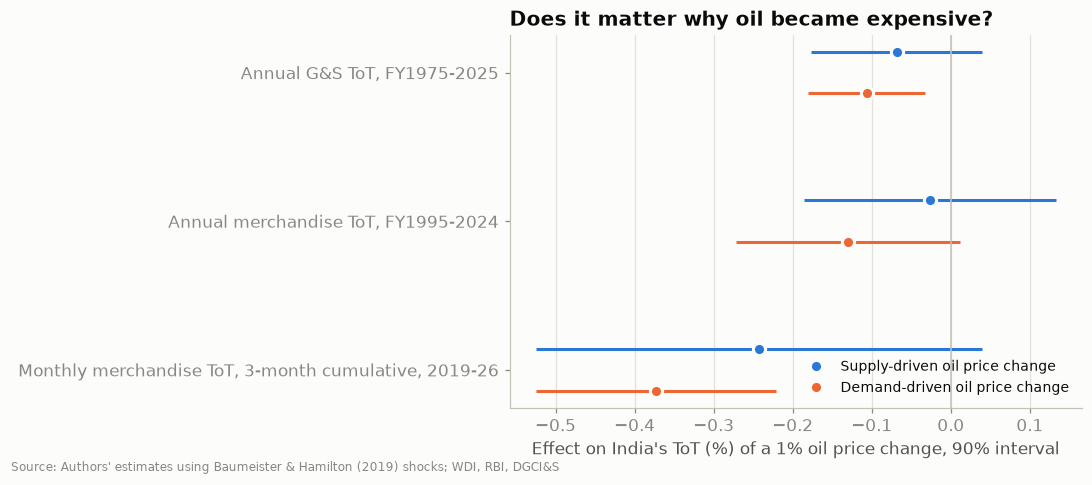

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.4))
yy = np.arange(len(h3))[::-1]
for off, col, se, colr, lab in ((0.14, "Supply-driven effect", "s.e. (supply)", BLUE, "Supply-driven oil price change"),
                                (-0.14, "Demand-driven effect", "s.e. (demand)", ORANGE, "Demand-driven oil price change")):
    ax.errorbar(h3[col], yy + off, xerr=1.645 * h3[se], fmt="o", ms=8, color=colr, mec=SURFACE, mew=2, elinewidth=2, capsize=0, label=lab)
ax.axvline(0, color=AXIS, lw=1)
ax.set_yticks(yy); ax.set_yticklabels(h3.index); ax.grid(axis="x"); ax.grid(axis="y", visible=False)
ax.set_xlabel("Effect on India's ToT (%) of a 1% oil price change, 90% interval")
ax.set_title("Does it matter why oil became expensive?")
ax.legend(loc="lower right", fontsize=9)
fig.tight_layout()
save(fig, "fig12_supply_vs_demand", "Authors' estimates using Baumeister & Hamilton (2019) shocks; WDI, RBI, DGCI&S")
plt.show()

## Robustness: Känzig (2021) oil supply news shocks

In [5]:
k = m.loc["1975-01":"2025-12", ["kanzig_news_shock"]].copy()
k["fy"] = [t.year if t.month >= 4 else t.year - 1 for t in k.index]
kf = k.groupby("fy").kanzig_news_shock.sum(min_count=12).rename("kanzig").to_frame().join(y).loc[1975:2024]
rk = smf.ols("dtot ~ kanzig", data=kf.dropna(subset=["dtot"])).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
mk = m.loc["2019-04":"2025-12", ["ntt_b12", "kanzig_news_shock"]].copy()
mk["l"] = 100 * np.log(mk.ntt_b12)
lpk = econ.local_projection(mk, "l", "kanzig_news_shock", horizons=6, controls_lags=1)
print(f"Annual: one unit of Känzig supply-news shock (raises oil about 10% on impact) changes G&S ToT by {rk.params['kanzig']:.2f}% (s.e. {rk.bse['kanzig']:.2f}), N={int(rk.nobs)}")
lpk

Annual: one unit of Känzig supply-news shock (raises oil about 10% on impact) changes G&S ToT by -0.95% (s.e. 0.49), N=50


,beta,se,N
h,,,
0,0.297,1.545,79
1,-1.250,1.747,78
2,-4.155,2.122,77
3,-4.668,1.711,76
4,-1.774,1.923,75
5,-0.913,1.943,74
6,-1.891,2.075,73


**Conclusion for H3: not supported, and the evidence points the other way.**
- Supply-driven oil price rises lower India's ToT, but **demand-driven rises do so at least as much**. The difference is not statistically significant, and the demand-driven effect is the more precisely estimated one.
- **Why the offer-curve intuition (case B) fails for India.** A global demand boom raises the prices of *all* the commodities India imports, not just oil: gold, coal, fertilisers, edible oils, metals. India's manufactured and services-linked exports gain less. Both offer curves shift, and the commodity-import effect dominates.
- **Känzig (2021) cross-check.** One standard supply-news shock (exogenous OPEC news) raises oil about 10%.
  - Annually it lowers India's ToT by about 1% (p ≈ 0.05), an elasticity of about −0.1, close to the supply-driven estimate above.
  - Monthly, the ToT falls by about 4–5% two to three months later (significant), an elasticity of about −0.4 to −0.5, close to the demand-driven estimate.
  - Purely supply-driven oil shocks clearly hurt India, but not by more than demand-driven ones.
- **Viva line:** "It matters *that* oil gets expensive more than *why*. India is a broad commodity importer, so demand booms hurt too."